# 07 - Multi-Category Experiments
Extend experiments beyond chairs to tables and storage furniture.
This demonstrates generalizability of the approach.

In [1]:
import sys, os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.config import load_config, ensure_dirs
from src.data.dataset_builder import DatasetBuilder
from src.data.dataset_index import DatasetIndex
from src.experiments.run_batch import run_batch_experiment
from src.experiments.summarize import summarize_results

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
cfg = load_config(os.path.join(PROJECT_ROOT, 'configs', 'multi_category.yaml'))
ensure_dirs(cfg)

categories = cfg['dataset']['categories']
print("Multi-category experiment:")
for cat in categories:
    print(f"  {cat['category']} - remove '{cat['semantic_label']}' ({cat['total_samples']} samples)")

Multi-category experiment:
  Chair - remove 'leg' (100 samples)
  Table - remove 'leg' (50 samples)
  StorageFurniture - remove 'door' (50 samples)


In [3]:
# Build datasets for each category
all_dfs = {}

for cat_cfg in categories:
    category = cat_cfg['category']
    label = cat_cfg['semantic_label']
    n_samples = cat_cfg['total_samples']

    data_dir = os.path.join(cfg['paths']['raw_data_dir'], f"{category}_{label}")
    out_dir = os.path.join(cfg['paths']['output_dir'], f"{category}_{label}")

    print(f"\n{'='*60}")
    print(f"Building dataset: {category} - {label}")
    print(f"{'='*60}")

    try:
        builder = DatasetBuilder(
            partnet_root=cfg['paths']['partnet_root'],
            output_dir=data_dir,
            category=category,
            semantic_label=label,
            total_samples=n_samples,
            random_seed=cfg['dataset']['random_seed'],
        )
        builder.build()

        # Run experiments
        print(f"\nRunning experiments...")
        df = run_batch_experiment(
            data_dir=data_dir,
            output_dir=out_dir,
            margin=cfg['repair']['margin'],
            proximity_threshold=cfg['repair']['proximity_threshold'],
            save_meshes=False,
        )
        df['category'] = category
        df['removed_part'] = label
        all_dfs[category] = df
        print(f"  {len(df)} samples evaluated")

    except Exception as e:
        print(f"  ERROR: {e}")

2026-04-13 01:34:48 [INFO] DatasetBuilder: Scanning PartNet for Chair with 'leg' parts...



Building dataset: Chair - leg


2026-04-13 01:34:59 [INFO] DatasetBuilder: Scan complete: 6519 valid, 24361 skipped                                    
2026-04-13 01:34:59 [INFO] DatasetBuilder: Selected 100 samples for dataset
Building dataset: 100%|██████████████████████████████████████████████████████████████| 100/100 [02:14<00:00,  1.35s/it]
2026-04-13 01:37:14 [INFO] DatasetBuilder: Dataset built: 100/100 samples saved to D:\MyJupyter\Works\3DPART\data\raw\Chair_leg
2026-04-13 01:37:14 [INFO] BatchExperiment: Running on 100 samples (SOTA=True, distance=True)



Running experiments...


Running experiments: 100%|█████████████████████████████████████████████████████████| 100/100 [1:54:32<00:00, 68.72s/it]
2026-04-13 03:31:46 [INFO] BatchExperiment: Done: 84 success, 16 failed
2026-04-13 03:31:46 [INFO] DatasetBuilder: Scanning PartNet for Table with 'leg' parts...


...

  28 samples evaluated

Building dataset: StorageFurniture - door


2026-04-13 04:39:40 [INFO] DatasetBuilder: Scan complete: 1304 valid, 29898 skipped                                    
2026-04-13 04:39:40 [INFO] DatasetBuilder: Selected 50 samples for dataset
Building dataset: 100%|████████████████████████████████████████████████████████████████| 50/50 [01:19<00:00,  1.59s/it]
2026-04-13 04:41:00 [INFO] DatasetBuilder: Dataset built: 50/50 samples saved to D:\MyJupyter\Works\3DPART\data\raw\StorageFurniture_door
2026-04-13 04:41:00 [INFO] BatchExperiment: Running on 50 samples (SOTA=True, distance=True)



Running experiments...


Running experiments:   6%|███▌                                                        | 3/50 [05:25<1:03:51, 81.53s/it]2026-04-13 04:46:25 [WARNING] BatchExperiment: Sample 47987: No boundary loops found
2026-04-13 04:46:26 [WARNING] BatchExperiment: Sample 47531: No boundary loops found
Running experiments:  20%|████████████▏                                                | 10/50 [18:14<55:14, 82.86s/it]2026-04-13 04:59:15 [WARNING] BatchExperiment: Sample 41129: No boundary loops found
2026-04-13 04:59:15 [WARNING] BatchExperiment: Sample 47654: No boundary loops found
Running experiments:  38%|██████████████████████                                    | 19/50 [41:56<1:02:52, 121.68s/it]2026-04-13 05:22:57 [WARNING] BatchExperiment: Sample 48343: No boundary loops found
2026-04-13 05:22:57 [WARNING] BatchExperiment: Sample 47595: No boundary loops found
2026-04-13 05:22:57 [WARNING] BatchExperiment: Sample 45843: No boundary loops found
Running experiments:  60%|██████████████████████

  32 samples evaluated


In [4]:
# Cross-category comparison
if all_dfs:
    df_all = pd.concat(all_dfs.values(), ignore_index=True)

    methods = {
        'Center-fan': 'center_fan',
        'Planar+RPA': 'planar_removed_part_aware',
        'Planar+LH': 'planar_largest_hole_only',
    }

    for cat_name, cat_df in all_dfs.items():
        print(f"\n--- {cat_name} ---")
        for display, prefix in methods.items():
            res_col = f'{prefix}/target_loop_length_after'
            loc_col = f'{prefix}/locality_ratio'
            qual_col = f'{prefix}/avg_new_face_quality'
            if res_col in cat_df.columns:
                print(f"  {display}: Residual={cat_df[res_col].mean():.4f}, "
                      f"Locality={cat_df[loc_col].mean():.4f}, "
                      f"Quality={cat_df[qual_col].mean():.4f}")


--- Chair ---
  Center-fan: Residual=0.0000, Locality=0.6656, Quality=0.2671
  Planar+RPA: Residual=1.9384, Locality=0.6710, Quality=0.4341
  Planar+LH: Residual=38.2569, Locality=0.5717, Quality=0.4122

--- Table ---
  Center-fan: Residual=0.0000, Locality=0.8511, Quality=0.3136
  Planar+RPA: Residual=0.7670, Locality=0.8654, Quality=0.4812
  Planar+LH: Residual=32.8290, Locality=0.6981, Quality=0.4639

--- StorageFurniture ---
  Center-fan: Residual=0.0000, Locality=0.1614, Quality=0.1135
  Planar+RPA: Residual=1.5902, Locality=0.1601, Quality=0.3799
  Planar+LH: Residual=72.5815, Locality=0.0557, Quality=0.3412


C:\Users\Administrator\AppData\Local\Temp\ipykernel_28068\69651708.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_28068\69651708.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_28068\69651708.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


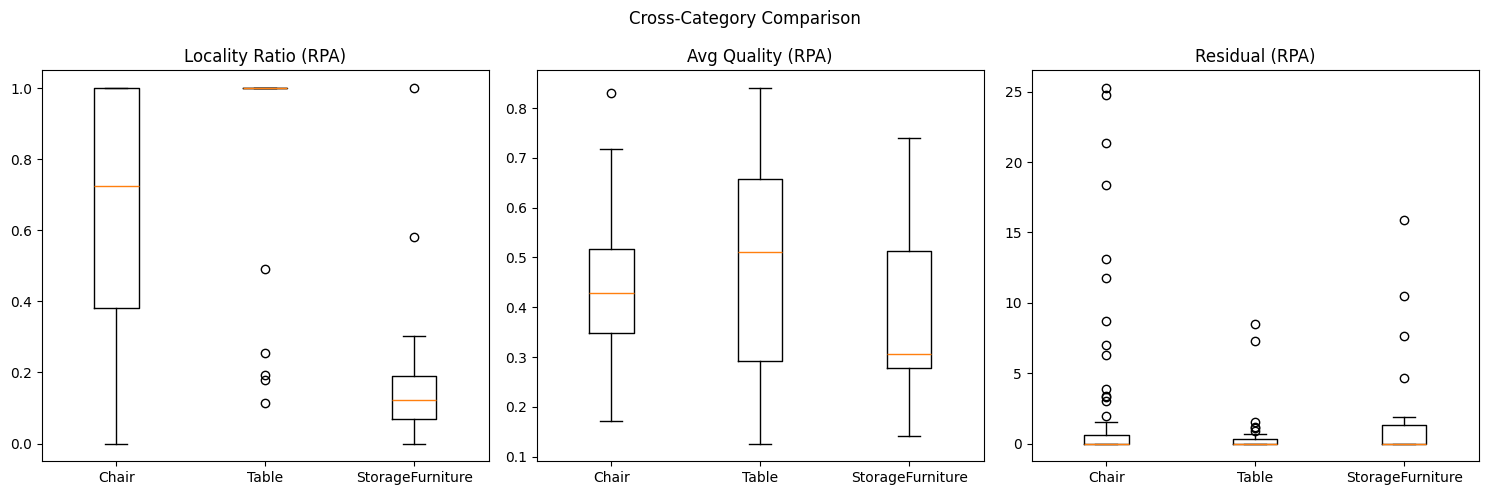

In [5]:
# Plot cross-category results
if len(all_dfs) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    metric_cols = [
        ('planar_removed_part_aware/locality_ratio', 'Locality Ratio (RPA)'),
        ('planar_removed_part_aware/avg_new_face_quality', 'Avg Quality (RPA)'),
        ('planar_removed_part_aware/target_loop_length_after', 'Residual (RPA)'),
    ]

    for ax, (col, title) in zip(axes, metric_cols):
        data = []
        labels = []
        for cat_name, cat_df in all_dfs.items():
            if col in cat_df.columns:
                data.append(cat_df[col].dropna().values)
                labels.append(cat_name)
        if data:
            ax.boxplot(data, labels=labels)
            ax.set_title(title)

    plt.suptitle('Cross-Category Comparison')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg['paths']['figures_dir'], 'multi_category_comparison.pdf'),
                dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Only one category available. Skipping cross-category plot.")